# Word Embeddings

Word Embedding is a technique that converts words into dense numerical vectors while preserving their semantic meaning.

In [1]:
import pandas as pd

train=pd.read_csv("engtamilTrain.csv")
train=train.drop(["Unnamed: 0"],axis=1)
english_sentences=train["en"]
tamil_sentence=train['ta']
english_sentences=english_sentences.head(1000)
tamil_sentences=tamil_sentence.head(1000)

In [2]:
from gensim.models import Word2Vec
from sklearn.decomposition import PCA
from matplotlib import pyplot

Word2Vec - This is the algorithm that learns word embeddings.
PCA reduces high-dimensional vectors to 2 dimensions so we can visualize them.

In [3]:
def sentToken(sentence):
    # define your dataset
    dataset = sentence

    # convert each sentence to a list of words
    sentences = [sentence.split() for sentence in dataset]

    # print the result
    print(sentences)
    
    return sentences


In [4]:
engSentence=sentToken(english_sentences)

[['MMA', 'vice', 'president', 'Qazi', 'Hussain', 'Ahmad', 'declared', 'last', 'month:', "'We", 'are', 'not', 'extremists.'], ['Information', 'has', 'surfaced', 'in', 'recent', 'years', 'suggesting', 'that', 'Julius', 'Rosenberg', 'was', 'involved', 'in', 'passing', 'some', 'form', 'of', 'intelligence', 'to', 'Soviet', 'officials', 'during', 'the', 'Second', 'World', 'War.'], ['And', 'Azor', 'begat', 'Sadoc;', 'and', 'Sadoc', 'begat', 'Achim;', 'and', 'Achim', 'begat', 'Eliud;'], ['She', 'says', 'she', 'knows', 'what', 'is', 'going', 'on,', 'but', 'can', 'do', 'nothing', 'about', 'it.'], ['And', 'be', 'it', 'indeed', 'that', 'I', 'have', 'erred,', 'my', 'error', 'remains', 'with', 'myself.'], ['Finally,', 'the', 'columnist', 'fails', 'to', 'tell', 'us', 'who', 'among', 'the', 'political', 'leaders', 'of', 'the', 'bourgeoisie,', 'past', 'and', 'present,', 'he', 'counts', 'among', 'the', 'paragons', 'of', 'morality.'], ['These', 'include', 'the', 'British', 'Tamil', 'Forum,', 'La', 'Maiso

In [5]:
tamSentence=sentToken(tamil_sentences)

[['MMA', 'கட்சியின்', 'துணைத்தலைவர்', 'க்வாஸி', 'ஹுசேன்', 'அகமத்', 'சென்ற', 'மாதம்', 'பின்வருமாறு', 'அறிவித்தார்:', '``நாங்கள்', 'தீவிரவாதிகள்', 'அல்ல.'], ['சமீபகாலத்தில்', 'சில', 'தகவல்கள்', 'யூலியஸ்', 'ரோசன்பேர்க்', 'ஒரு', 'வித', 'உளவுச்செய்தியை', 'சோவியத்', 'அதிகாரிகளுக்கு', 'இரண்டாம்', 'உலகப்போரின்போது', 'அனுப்பியதில்', 'சம்பந்தப்பட்டு', 'இருந்ததாக', 'வெளிவந்துள்ளன.'], ['ஆசோர்', 'சாதோக்கைப்', 'பெற்றான்;', 'சாதோக்கு', 'ஆகீமைப்', 'பெற்றான்;', 'ஆகீம்', 'எலியூதைப்', 'பெற்றான்;'], ['என்ன', 'நடக்கிறது', 'என்பது', 'தமக்கு', 'தெரியும்', 'என்றும்', 'ஆனால்,', 'தம்மால்', 'எதுவும்', 'செய்யமுடியாது', 'என்றும்', 'கடிதம்', 'எழுதியிருந்தார்.'], ['நான்', 'தப்பிநடந்தது', 'மெய்யானாலும்,', 'என்', 'தப்பிதம்', 'என்னோடேதான்', 'இருக்கிறது'], ['டால்ரிம்பிளினுடைய', 'அறிவுஜீவித்', 'தொடுவானத்திற்கு', 'அப்பால்', 'எவ்வளவோ', 'தொலைவில்', 'இருந்தன'], ['இந்த', 'அமைப்புக்களில்', 'British', 'Tamil', 'Forum,', 'La', 'Maison', 'du', 'Tamil', 'Eelam', '(France),', 'the', 'Canadian', 'Tamil', 'Congress,', 'Swiss',

In [6]:
def ownWordModel(langsentence,modelname):
    import matplotlib.pyplot as plt
    # Word2Vec reads all the tokenized sentences and learns a vector for every word.
    # min_count=1 means keep every word, even if it appears only once.
    model = Word2Vec(langsentence, min_count=1)
    
    print(model)
    # save model
    model.save(modelname)
    
    # fit a 2d PCA model to the vectors
    # Gets the learned vectors.
    # By default gensim creates vectors of size 100.
    # If there are 5000 unique words and each vector has 100 values, X has shape: (5000,100). Each row is the embedding for one word.
    X = model.wv.vectors 
    
    # Reduces the vectors from 100 dimensions to 2 dimensions.
    pca = PCA(n_components=2)

    # Performs the dimensionality reduction. Now each word has 2 coordinates king - (0.23, 0.57)
    result = pca.fit_transform(X)

    # create a scatter plot of the projection
    # Plots all the words as dots on a graph.
    plt.scatter(result[:, 0], result[:, 1])
    # Gets all the vocabulary words.
    words = list(model.wv.index_to_key)

    # Loops through every word and its index.
    for i, word in enumerate(words):
        #Writes the word next to its dot.
        plt.annotate(word, xy=(result[i, 0], result[i, 1]))
    plt.show()


Word2Vec<vocab=7300, vector_size=100, alpha=0.025>


C:\Users\ADMIN\anaconda3\envs\aimlcourse\lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 128 (\x80) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\ADMIN\anaconda3\envs\aimlcourse\lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 147 (\x93) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\ADMIN\anaconda3\envs\aimlcourse\lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 130 (\x82) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\ADMIN\anaconda3\envs\aimlcourse\lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 159 (\x9f) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


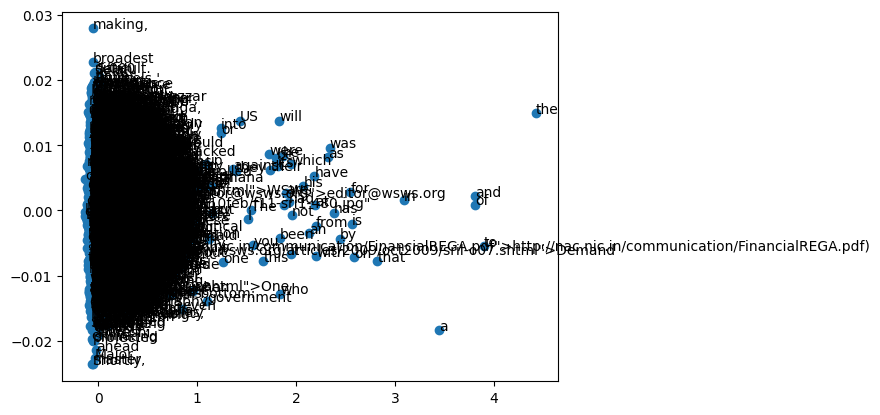

In [7]:
# Trains and saves the English Word2Vec model.
ownWordModel(engSentence,"engmodel.bin")

Word2Vec<vocab=9882, vector_size=100, alpha=0.025>


C:\Users\ADMIN\anaconda3\envs\aimlcourse\lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 2962 (\N{TAMIL LETTER O}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\ADMIN\anaconda3\envs\aimlcourse\lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Matplotlib currently does not support Tamil natively.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\ADMIN\anaconda3\envs\aimlcourse\lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 2992 (\N{TAMIL LETTER RA}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\ADMIN\anaconda3\envs\aimlcourse\lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 3009 (\N{TAMIL VOWEL SIGN U}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\ADMIN\anaconda3\envs\aimlcourse\lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 2990 (\N{TAMIL LETTER MA}) missing from current font.
  fig.canvas.pri

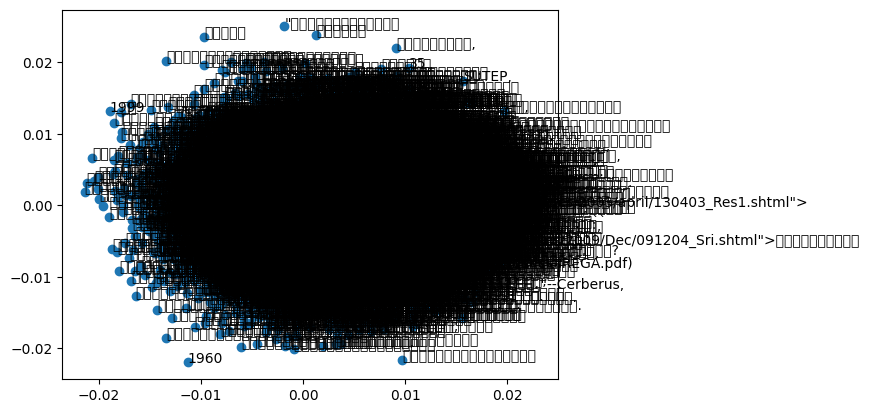

In [8]:
# Trains and saves the Tamil Word2Vec model.
ownWordModel(tamSentence,"tammodel.bin")

In [9]:
model = Word2Vec.load("engmodel.bin")

print(model.wv.index_to_key[:20])

print(model.wv["Barnabas"])     
print(model.wv["Kamalahasan"]) 

['the', 'of', 'and', 'to', 'in', 'a', 'that', 'is', 'for', 'The', 'by', 'on', 'was', 'with', 'as', 'he', 'has', 'be', 'have', 'his']
[ 0.00456769  0.00757297  0.00163409  0.00568607 -0.00791703  0.00031194
  0.0001476  -0.00066252 -0.00467404  0.00296337  0.00243214 -0.0043074
  0.00096594  0.00179975  0.00288406 -0.00626238 -0.0051251   0.00844061
 -0.00631765 -0.00234402  0.00703137 -0.00124082  0.00105569  0.00470618
  0.00642563 -0.00458162  0.00095873  0.008132   -0.00648132  0.00055435
  0.00060811 -0.00012107  0.0125973  -0.00620367 -0.00564577  0.00981211
 -0.00674071 -0.00325141 -0.00681298  0.00198453 -0.00396727 -0.01301656
 -0.01138052 -0.00395335  0.00806673 -0.01089935 -0.00765519 -0.0077055
  0.00056877  0.00053863 -0.00386807  0.00036787  0.00123497 -0.0060088
  0.00480144 -0.00559233  0.01242693 -0.00969638  0.0073784   0.00550212
  0.00760352 -0.00816984  0.00818353  0.0038407  -0.00234192 -0.00405896
  0.00781758  0.00979442 -0.00581303  0.00775267 -0.00476456  0.009